In [1]:
import cupy as cp
import numpy as np
import cupyx.scipy.ndimage as ndimage
from types import SimpleNamespace
import tifffile
from utils import *
from rec import Rec
np.random.seed(10)
cp.random.seed(10)

%matplotlib inline

In [2]:
n = 270    
ntheta = 1
ndist = 4


detector_pixelsize = 55e-6
energy = 30  # [keV] xray energy
wavelength = 1.24e-09/energy  # [m] wave length

focusToDetectorDistance = 8.4644-0.6475  # [m]
sx0 = 0.6475
z1 = np.array([0.6532, 0.6552, 0.6572, 0.6592])[:ndist]-sx0


z2 = focusToDetectorDistance-z1
distances = z1 * z2 / focusToDetectorDistance
magnifications = focusToDetectorDistance / z1
norm_magnifications = magnifications / magnifications[0]
voxelsize = np.abs(detector_pixelsize / magnifications[0])
print(voxelsize)

4.010541263160615e-08


### Adjust distances for the cone beam: sample - detector, probe - sample

## Reconstructed object size

In [3]:
nobj = 270
print(f'Reconstructed object size {nobj}x{nobj}')

Reconstructed object size 270x270


In [4]:


nref = 1
ndark = 1
data = np.zeros([ntheta,ndist,n,n],dtype='uint16')
ref = np.zeros([nref,ndist,n,n],dtype='uint16')
dark = np.zeros([ndark,ndist,n,n],dtype='uint16')
for k in range(ndist):
    data[:,k] = tifffile.imread(f'img_{k:04d}.tif')
    ref[:,k] = tifffile.imread(f'flat_{k:04d}.tif')
    dark[:,k] = np.zeros((nobj, nobj))

print(f'data shape {data.shape}')
print(f'flats shape {ref.shape}')
print(f'darks shape {dark.shape}')


data shape (1, 4, 270, 270)
flats shape (1, 4, 270, 270)
darks shape (1, 4, 270, 270)


In [19]:
# Form reconstruction parameters
rargs = SimpleNamespace(
    ndist=ndist,
    ntheta=ntheta,
    energy=energy,        
    focusToDetectorDistance=focusToDetectorDistance,        
    z1=z1,       
    obj_dtype='complex64',    
    n = n,
    nz = n,
    nobj = nobj,
    nzobj = nobj,
    detector_pixelsize = detector_pixelsize,           
)
cl = Rec(rargs)


Adjusted distances sample-detector [0.00569584 0.00421532 0.00334533 0.00277277]
Adjusted distances probe-sample [0.         0.00148052 0.00235052 0.00292308]
Sums adjusted [0.00569584 0.00569584 0.00569584 0.00569584]
Voxelsize for reconstruction 4.010541263160615e-08


## normalize with mean (ref)

In [20]:
mean_ref = cp.mean(ref)
data/=mean_ref
ref/=mean_ref

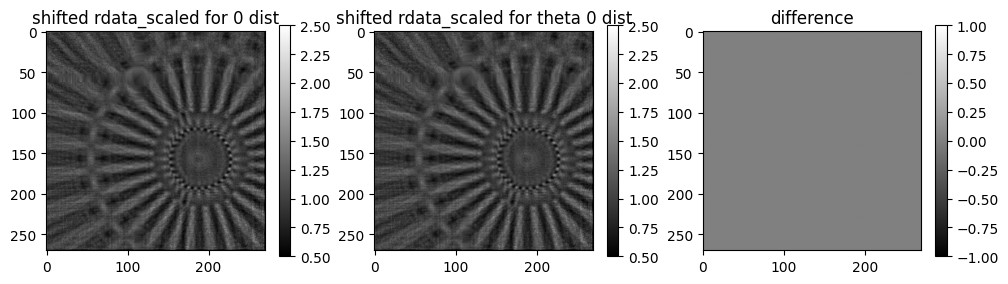

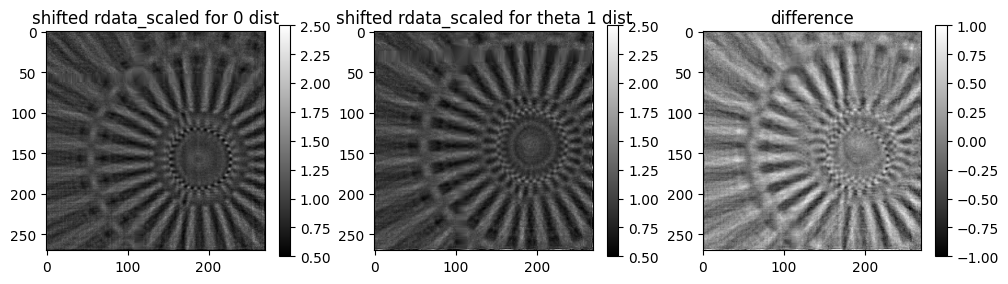

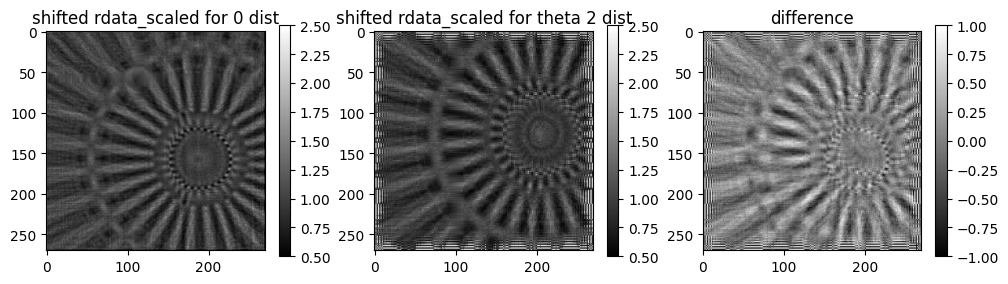

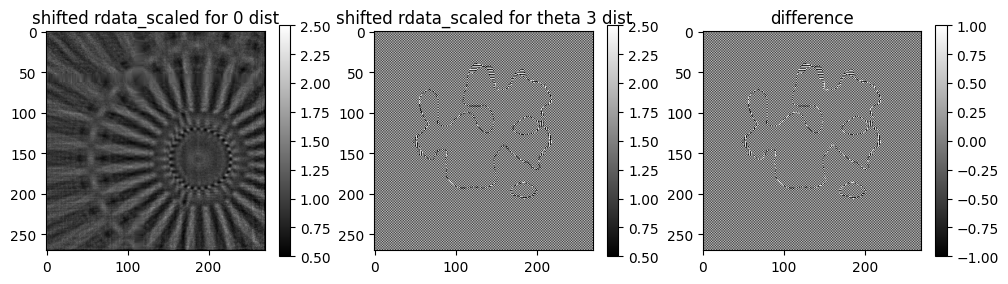

In [21]:
#Alignment does work. Does not work above as above pos is zero!
import cupyx.scipy.ndimage as nd

rdata_scaled = cp.zeros([ntheta,ndist,nobj,nobj],dtype='float32')
pos = cp.zeros([ntheta,ndist,2],dtype='float32')

for k in range(ndist):
    rdata_scaled[:, k] = cl.cl_shift.curlySback(rdata[:,k].astype('complex64'),pos,k).real
    rdata_scaled[:, k]/=norm_magnifications[k]**2


rdata_scaled = rdata_scaled[:,:,nobj//2-n//2:nobj//2+n//2,nobj//2-n//2:nobj//2+n//2]
for k in range(ndist):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3))
    im = axs[0].imshow(rdata_scaled[0, 0].get(), cmap='gray', vmin=0.5, vmax=2.5)
    axs[0].set_title(f'shifted rdata_scaled for 0 dist')
    fig.colorbar(im)
    im = axs[1].imshow(rdata_scaled[0, k].get(), cmap='gray', vmin=0.5, vmax=2.5)
    axs[1].set_title(f'shifted rdata_scaled for theta {k} dist')
    fig.colorbar(im)
    im = axs[2].imshow(rdata_scaled[0, k].get()-rdata_scaled[0, 0].get(), cmap='gray', vmin=-1, vmax=1)
    axs[2].set_title(f'difference')
    fig.colorbar(im)

#rdata_scaled = rdata_aligned


In [22]:
def CTFPurePhase(data, distances, wavelength, voxelsize, alpha):

    fx = cp.fft.fftfreq(data.shape[-1], d=voxelsize).astype('float32')
    [fx, fy] = cp.meshgrid(fx, fx)
    numerator = 0
    denominator = 0
    for j in range(0, len(distances)):
        rad_freq = cp.fft.fft2(data[:, j])
        taylorExp = cp.sin(cp.pi*wavelength*distances[j]*(fx**2+fy**2))
        numerator = numerator + taylorExp * (rad_freq)
        denominator = denominator + 2*taylorExp**2
    numerator = numerator / len(distances)
    denominator = (denominator / len(distances)) + alpha
    phase = cp.real(cp.fft.ifft2(numerator / denominator))
    phase = 0.5 * phase
    return phase

def _upsampled_dft(data, ups,
                   upsample_factor=1, axis_offsets=None):

    im2pi = 1j * 2 * np.pi
    tdata = data.copy()
    kernel = (cp.tile(cp.arange(ups), (data.shape[0], 1))-axis_offsets[:, 1:2])[
        :, :, None]*cp.fft.fftfreq(data.shape[2], upsample_factor)
    kernel = cp.exp(-im2pi * kernel)
    tdata = cp.einsum('ijk,ipk->ijp', kernel, tdata)
    kernel = (cp.tile(cp.arange(ups), (data.shape[0], 1))-axis_offsets[:, 0:1])[
        :, :, None]*cp.fft.fftfreq(data.shape[1], upsample_factor)
    kernel = cp.exp(-im2pi * kernel)
    rec = cp.einsum('ijk,ipk->ijp', kernel, tdata)

    return rec

def registration_shift(src_image, target_image, upsample_factor=1, space="real"):
    
    # assume complex data is already in Fourier space
    if space.lower() == 'fourier':
        src_freq = src_image
        target_freq = target_image
    # real data needs to be fft'd.
    elif space.lower() == 'real':
        src_freq = cp.fft.fft2(src_image)
        target_freq = cp.fft.fft2(target_image)

    # Whole-pixel shift - Compute cross-correlation by an IFFT
    shape = src_freq.shape
    image_product = src_freq * target_freq.conj()
    cross_correlation = cp.fft.ifft2(image_product)
    A = cp.abs(cross_correlation)
    maxima = A.reshape(A.shape[0], -1).argmax(1)
    maxima = cp.column_stack(cp.unravel_index(maxima, A[0, :, :].shape))

    midpoints = cp.array([cp.fix(axis_size / 2)
                          for axis_size in shape[1:]])

    shifts = cp.array(maxima, dtype=np.float32)
    ids = cp.where(shifts[:, 0] > midpoints[0])
    shifts[ids[0], 0] -= shape[1]
    ids = cp.where(shifts[:, 1] > midpoints[1])
    shifts[ids[0], 1] -= shape[2]

    if upsample_factor > 1:
        # Initial shift estimate in upsampled grid
        shifts = cp.round(shifts * upsample_factor) / upsample_factor
        upsampled_region_size = cp.ceil(upsample_factor * 1.5)
        # Center of output array at dftshift + 1
        dftshift = cp.fix(upsampled_region_size / 2.0)

        normalization = (src_freq[0].size * upsample_factor ** 2)
        # Matrix multiply DFT around the current shift estimate

        sample_region_offset = dftshift - shifts*upsample_factor
        cross_correlation = _upsampled_dft(image_product.conj(),
                                           upsampled_region_size,
                                           upsample_factor,
                                           sample_region_offset).conj()
        cross_correlation /= normalization
        # Locate maximum and map back to original pixel grid
        A = cp.abs(cross_correlation)
        maxima = A.reshape(A.shape[0], -1).argmax(1)
        maxima = cp.column_stack(
            cp.unravel_index(maxima, A[0, :, :].shape))

        maxima = cp.array(maxima, dtype=np.float32) - dftshift

        shifts = shifts + maxima / upsample_factor
        print(shifts)

    return shifts

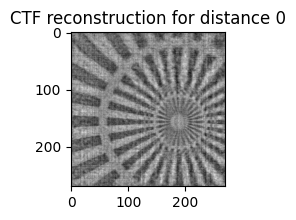

[[-15.753   4.248]]
[[-30.329  15.723]]
[[-51.045 -90.958]]
[[[  0.      0.   ]
  [-15.753   4.248]
  [-30.329  15.723]
  [-51.045 -90.958]]]


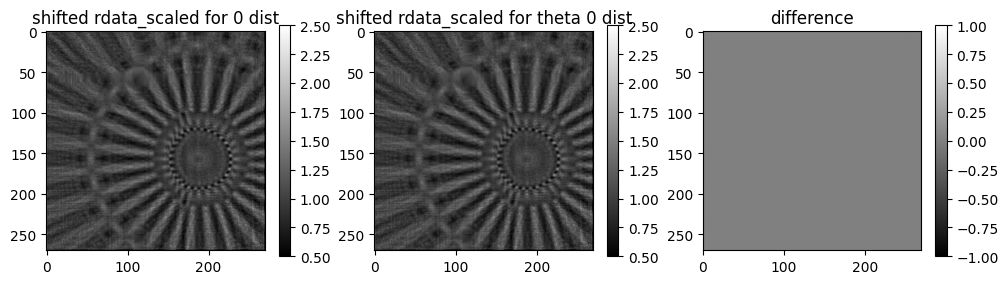

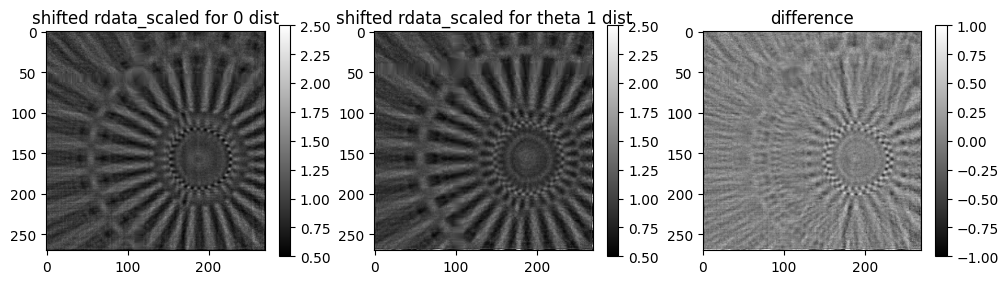

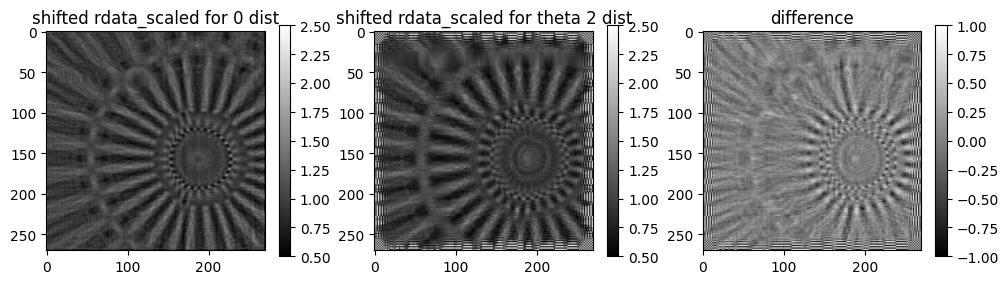

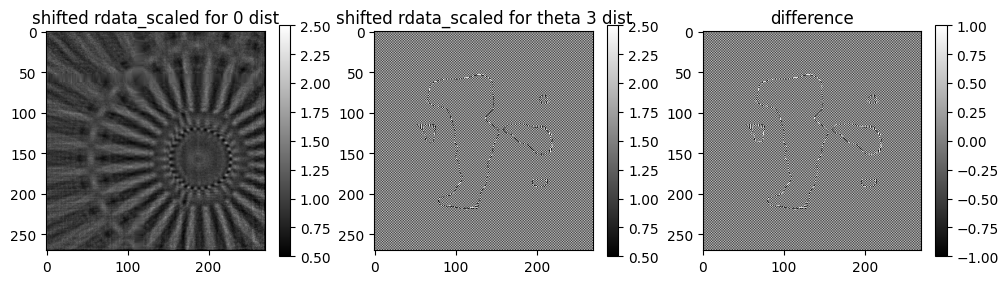

In [23]:
recCTF_1dist = cp.zeros([ntheta, ndist, n, n], dtype='float32')
distances_ctf = (distances)[:ndist]

for k in range(ndist):
    recCTF_1dist[:, k] = CTFPurePhase(
        rdata_scaled[:, k:k+1], distances_ctf[k:k+1],wavelength, voxelsize,  1e-1)

plt.figure(figsize=(2, 2))
plt.title(f'CTF reconstruction for distance {ndist-4}')
plt.imshow(recCTF_1dist[0, -4].get(), cmap='gray')
plt.show()

pos = cp.zeros([ntheta, ndist, 2], dtype='float32')

for k in range(1, ndist):
    pos[:, k] = registration_shift(
        recCTF_1dist[:, k], recCTF_1dist[:, 0], upsample_factor=1000)

print(pos)

rdata_scaled = cp.zeros([ntheta,ndist,nobj,nobj],dtype='float32')
for k in range(ndist):
    rdata_scaled[:, k] = cl.cl_shift.curlySback(rdata[:,k].astype('complex64'),pos[:,k],k).real
    rdata_scaled[:, k]/=norm_magnifications[k]**2

rdata_scaled = rdata_scaled[:,:,nobj//2-n//2:nobj//2+n//2,nobj//2-n//2:nobj//2+n//2]
for k in range(ndist):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3))
    im = axs[0].imshow(rdata_scaled[0, 0].get(), cmap='gray', vmin=0.5, vmax=2.5)
    axs[0].set_title(f'shifted rdata_scaled for 0 dist')
    fig.colorbar(im)
    im = axs[1].imshow(rdata_scaled[0, k].get(), cmap='gray', vmin=0.5, vmax=2.5)
    axs[1].set_title(f'shifted rdata_scaled for theta {k} dist')
    fig.colorbar(im)
    im = axs[2].imshow(rdata_scaled[0, k].get()-rdata_scaled[0, 0].get(), cmap='gray', vmin=-1, vmax=1)
    axs[2].set_title(f'difference')
    fig.colorbar(im)

## Solving with the BH method:
### $ \argmin_{\delta,\beta,p,r}\|\sqrt{d_j} - |\mathcal{D}_{z_j}(\mathcal{D}_{z'_j}(p)\cdot e^{i\mathcal{S}_{r_j} ( \delta+i\beta) })|\|^2_2 +\lambda\|D_z (p) - \sqrt{d^r}\|_2^2 +\lambda_r\|\Delta (\delta+i\beta)\|_2^2$, 
### where $\mathcal{S}_{r_j}$ is a shift+magnification for distance $j$ 
### $r_j$ - (x,y) sample positions at distance $j$ given in pixels for original scaling
### $\lambda\|D_z (p) - \sqrt{d^r}\|_2^2$ - probe fit term
### $\lambda_r\|\Delta (\delta+i\beta)\|_2^2$ - regularization term


Adjusted distances sample-detector [0.00569584 0.00421532 0.00334533 0.00277277]
Adjusted distances probe-sample [0.         0.00148052 0.00235052 0.00292308]
Sums adjusted [0.00569584 0.00569584 0.00569584 0.00569584]
Voxelsize for reconstruction 4.010541263160615e-08
iter=-1: err=8.90824e-02 
iter=0: err=5.56276e-03 


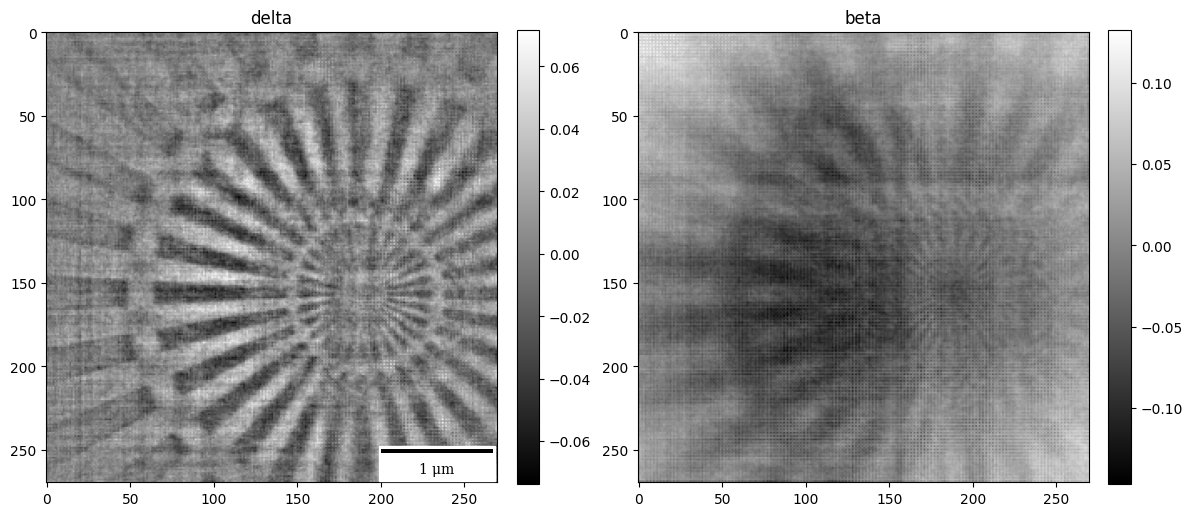

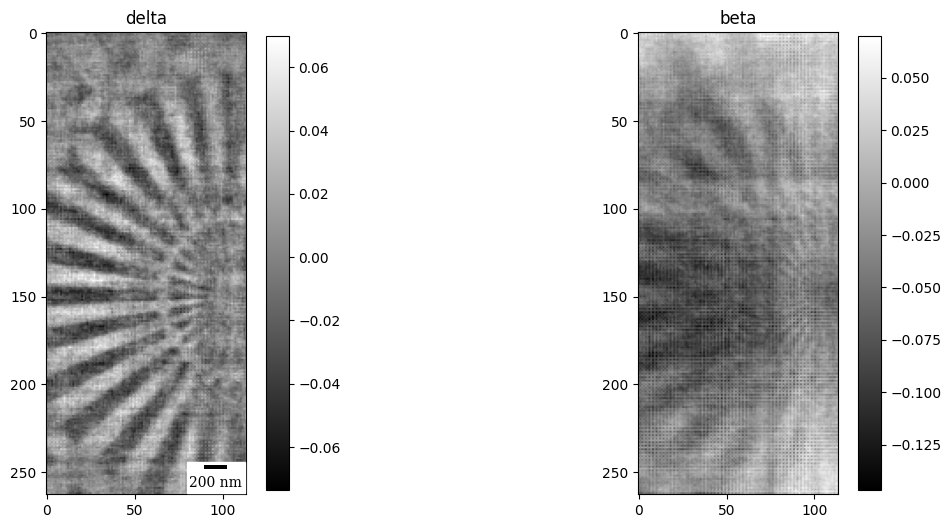

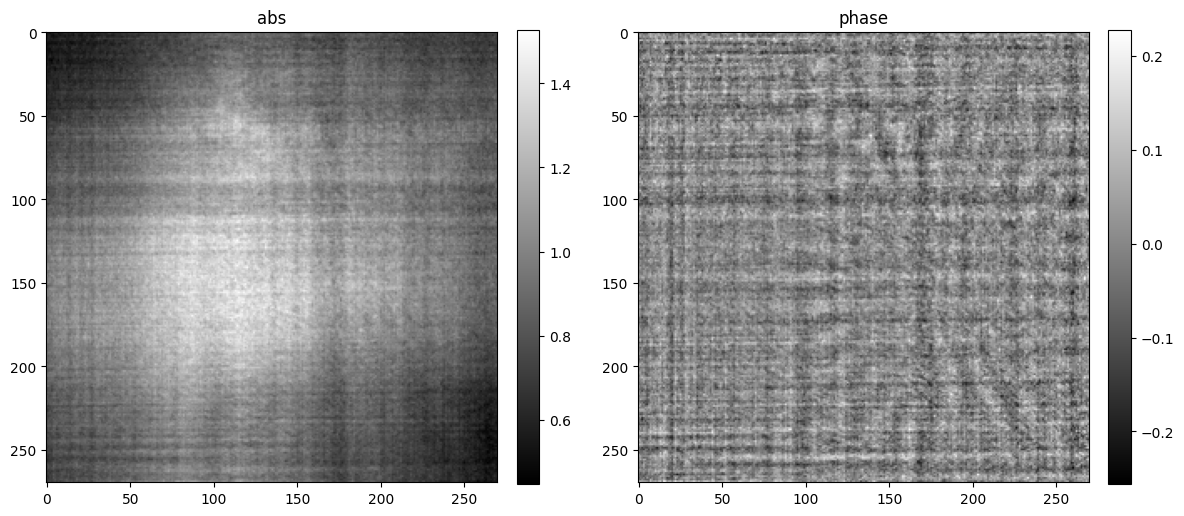

iter=1: err=4.06803e-03 
iter=2: err=3.44033e-03 
iter=3: err=3.13972e-03 
iter=4: err=2.85717e-03 
iter=5: err=2.74742e-03 
iter=6: err=2.64011e-03 
iter=7: err=2.59151e-03 
iter=8: err=2.55977e-03 
iter=9: err=2.54245e-03 
iter=10: err=2.48419e-03 
iter=11: err=2.46703e-03 
iter=12: err=2.46177e-03 
iter=13: err=2.42840e-03 
iter=14: err=2.41372e-03 
iter=15: err=2.40992e-03 
iter=16: err=2.38387e-03 
iter=17: err=2.37150e-03 
iter=18: err=2.36489e-03 
iter=19: err=2.36166e-03 
iter=20: err=2.35512e-03 
iter=21: err=2.35198e-03 
iter=22: err=2.34830e-03 
iter=23: err=2.34481e-03 
iter=24: err=2.33875e-03 
iter=25: err=2.33507e-03 
iter=26: err=2.33297e-03 
iter=27: err=2.33050e-03 
iter=28: err=2.32740e-03 
iter=29: err=2.32429e-03 
iter=30: err=2.31642e-03 
iter=31: err=2.31144e-03 
iter=32: err=2.30971e-03 
iter=33: err=2.30429e-03 
iter=34: err=2.30097e-03 
iter=35: err=2.29909e-03 
iter=36: err=2.29685e-03 
iter=37: err=2.29402e-03 
iter=38: err=2.29118e-03 
iter=39: err=2.28415e

KeyboardInterrupt: 

In [18]:


rargs.niter = 2049 # number of iterations
rargs.vis_step = 500 # visualization step
rargs.err_step = 1  # error step
rargs.lam_prbfit = 1
rargs.lam_reg = 0.1 # regularization (if noisy)
rargs.rho = {'proj':1,'prb':1,'pos':0.05} # scaling variables

vars = {}
vars['prb'] = cp.ones([n,n],dtype='complex64')
vars['pos'] = pos
vars['proj'] = cp.zeros([ntheta,nobj,nobj],dtype='complex64') # can be also estimated with e.g. multiPaganin
cl = Rec(rargs)    
cl.BH(data,ref[0],vars)

#My test of probe init
'''
print(type(pos))
rargs.niter = 2049 # number of iterations
rargs.vis_step = 10 # visualization step
rargs.err_step = 10  # error step
rargs.lam_prbfit = 1
rargs.lam_reg = 0.1 # regularization (if noisy)
rargs.rho = {'proj':1,'prb':1,'pos':0.05} # scaling variables

vars = {}
#vars['prb'] = cp.ones([n,n],dtype='complex64')
#vars['pos'] = pos
#vars['proj'] = cp.zeros([ntheta,nobj,nobj],dtype='complex64') # can be also estimated with e.g. multiPaganin

print(pos)

vars['prb'] = cp.asarray(
    np.sqrt(tifffile.imread('illumination_intensity.tif').astype(np.float32)) *
    np.exp(1j * tifffile.imread('illumination_phase.tif').astype(np.float32)),
    dtype=cp.complex64
)
vars['pos'] = pos
vars['proj'] = recCTF_1dist[:, 0, :, :].astype(cp.complex64)

print("proj shape:", vars["proj"].shape)
print("data shape:", data.shape)
print("ref shape:", ref.shape)

cl = Rec(rargs)    
cl.BH(data,ref[0],vars)
'''

